# 04 — Generalisation Test: Google-trained agent on Alibaba workload

Tests whether the PPO agent trained **only** on Google Cluster Trace 2011
still beats the rule-based HPA baseline when evaluated on a workload derived
from the **Alibaba Cluster Trace 2018** — without any retraining.

This is a cross-provider generalisation test. Run top-to-bottom.

## 1. Setup, constants, and environment

In [1]:
import json

from env import CloudClusterEnv, STEPS_PER_WEEK

Setup complete. Steps per week: 672
CloudClusterEnv defined.


## 2. The trained network architecture (must match saved model)

In [2]:
import numpy as np
import torch
import torch.nn as nn
from torch.distributions import Normal

# import your environment from notebook 02
# (easiest for now: paste the CloudClusterEnv cell into this notebook too,
#  OR use %run — we'll handle imports cleanly in a moment)

class ActorCritic(nn.Module):
    def __init__(self, state_dim=32, action_dim=1):
        super().__init__()

        # shared body — both actor and critic read the state through this
        self.shared = nn.Sequential(
            nn.Linear(state_dim, 256), nn.Tanh(),
            nn.Linear(256, 256),       nn.Tanh(),
        )

        # actor head: outputs the MEAN of the action distribution
        self.actor_mean = nn.Linear(256, action_dim)

        # a single learnable log-std (not state-dependent) — standard for PPO.
        # controls how much the agent explores around the mean.
        self.log_std = nn.Parameter(torch.zeros(action_dim))

        # critic head: outputs V(s), one number
        self.critic = nn.Linear(256, 1)

    def forward(self, state):
        x = self.shared(state)
        mean = self.actor_mean(x)
        value = self.critic(x)
        return mean, value

    def get_action(self, state):
        """Sample an action (training) and return its log-prob + value."""
        mean, value = self.forward(state)
        std = torch.exp(self.log_std)          # log_std -> std, always positive
        dist = Normal(mean, std)               # Gaussian over the action
        action = dist.sample()                 # sample for exploration
        log_prob = dist.log_prob(action).sum(-1)
        return action, log_prob, value.squeeze(-1)

    def evaluate_actions(self, state, action):
        """Used during the PPO update: re-score stored actions."""
        mean, value = self.forward(state)
        std = torch.exp(self.log_std)
        dist = Normal(mean, std)
        log_prob = dist.log_prob(action).sum(-1)
        entropy = dist.entropy().sum(-1)
        return log_prob, value.squeeze(-1), entropy

## 3. Evaluation functions

In [3]:
def run_ppo(env, net, n_episodes=5):
    """Run the trained PPO agent (deterministic: use the mean action)
    over several weeks and average the metrics."""
    all_results = []
    for _ in range(n_episodes):
        obs, _ = env.reset()
        obs = torch.tensor(obs, dtype=torch.float32)
        total_cost = total_breaches = total_util = 0.0
        vm_counts = []
        steps = 0
        for t in range(STEPS_PER_WEEK):
            with torch.no_grad():
                mean, _ = net.forward(obs.unsqueeze(0))   # MEAN = deterministic
            action = mean.squeeze(0).numpy()
            obs, reward, done, truncated, info = env.step(action)
            obs = torch.tensor(obs, dtype=torch.float32)
            total_cost += info['cost']
            total_breaches += info['breaches']
            total_util += info['utilisation']
            vm_counts.append(info['active_vms'])
            steps += 1
            if done:
                break
        all_results.append({
            'total_cost': total_cost,
            'total_breaches': total_breaches,
            'avg_utilisation': total_util / steps,
            'avg_vms': np.mean(vm_counts),
        })
    return all_results


def run_rule_based(env, up_threshold=0.70, down_threshold=0.30):
    """Rule-based HPA-equivalent baseline."""
    obs, _ = env.reset()
    total_cost = total_breaches = total_util = 0.0
    vm_counts = []
    steps = 0
    for t in range(STEPS_PER_WEEK):
        current_avg_cpu = env.history[-1][0]
        if current_avg_cpu > up_threshold:
            action = np.array([0.2])
        elif current_avg_cpu < down_threshold:
            action = np.array([-0.2])
        else:
            action = np.array([0.0])
        obs, reward, done, truncated, info = env.step(action)
        total_cost += info['cost']
        total_breaches += info['breaches']
        total_util += info['utilisation']
        vm_counts.append(info['active_vms'])
        steps += 1
        if done:
            break
    return {'total_cost': total_cost, 'total_breaches': total_breaches,
            'avg_utilisation': total_util / steps, 'avg_vms': np.mean(vm_counts)}

print("Evaluation functions defined.")

Evaluation functions defined.


## 4. Generalisation test

Swap the simulator's workload to the Alibaba-derived pattern, load the
Google-trained `sla-focused` model, and compare it against HPA on Alibaba —
**no retraining**.

In [4]:
# swap simulator workload to Alibaba
with open('alibaba_params.json') as f:
    alibaba_data = json.load(f)
alibaba_stats = alibaba_data['stats']            # <-- simulator now generates Alibaba workload
print("Simulator now using ALIBABA workload.\n")

# load best Google-trained model
gen_net = ActorCritic()
gen_net.load_state_dict(torch.load('ppo_sla-focused.pth'))
gen_net.eval()
print("Loaded Google-trained sla-focused model.\n")

# run trained agent on Alibaba (no retraining)
env = CloudClusterEnv(alibaba_stats)
ppo_ali = run_ppo(env, gen_net, n_episodes=5)
ppo_cost   = np.mean([r['total_cost'] for r in ppo_ali])
ppo_breach = np.mean([r['total_breaches'] for r in ppo_ali])
ppo_util   = np.mean([r['avg_utilisation'] for r in ppo_ali])
ppo_vms    = np.mean([r['avg_vms'] for r in ppo_ali])

# run HPA baseline on same Alibaba workload
env = CloudClusterEnv(alibaba_stats)
hpa_ali = [run_rule_based(env) for _ in range(5)]
hpa_cost   = np.mean([r['total_cost'] for r in hpa_ali])
hpa_breach = np.mean([r['total_breaches'] for r in hpa_ali])
hpa_util   = np.mean([r['avg_utilisation'] for r in hpa_ali])
hpa_vms    = np.mean([r['avg_vms'] for r in hpa_ali])

# results
print("="*54)
print("GENERALISATION — Alibaba 2018 (PPO trained ONLY on Google)")
print("="*54)
print(f"{'METRIC':<22}{'HPA':>14}{'PPO':>14}")
print("-"*54)
print(f"{'Total cost':<22}{hpa_cost:>14.1f}{ppo_cost:>14.1f}")
print(f"{'SLA breaches':<22}{hpa_breach:>14.0f}{ppo_breach:>14.0f}")
print(f"{'Utilisation':<22}{hpa_util:>14.3f}{ppo_util:>14.3f}")
print(f"{'Avg VMs':<22}{hpa_vms:>14.1f}{ppo_vms:>14.1f}")
print("="*54)
cost_d = (ppo_cost - hpa_cost)/hpa_cost*100
breach_d = (ppo_breach - hpa_breach)/hpa_breach*100 if hpa_breach>0 else float('nan')
print(f"\nPPO vs HPA on Alibaba:  cost {cost_d:+.1f}%,  breaches {breach_d:+.1f}%")

Simulator now using ALIBABA workload.

Loaded Google-trained sla-focused model.

GENERALISATION — Alibaba 2018 (PPO trained ONLY on Google)
METRIC                           HPA           PPO
------------------------------------------------------
Total cost                     567.4         233.1
SLA breaches                       0         16840
Utilisation                    0.476         0.988
Avg VMs                         16.9           6.9

PPO vs HPA on Alibaba:  cost -58.9%,  breaches +nan%


In [5]:
env = CloudClusterEnv(alibaba_stats)
obs, _ = env.reset()
obs = torch.tensor(obs, dtype=torch.float32)
vms_over_time = []
for t in range(STEPS_PER_WEEK):
    with torch.no_grad():
        mean, _ = gen_net.forward(obs.unsqueeze(0))
    obs, r, done, tr, info = env.step(mean.squeeze(0).numpy())
    obs = torch.tensor(obs, dtype=torch.float32)
    vms_over_time.append(info['active_vms'])
    if done: break

import numpy as np
print(f"VM count over Alibaba week: min {min(vms_over_time)}, "
      f"max {max(vms_over_time)}, mean {np.mean(vms_over_time):.1f}, "
      f"std {np.std(vms_over_time):.1f}")

VM count over Alibaba week: min 2, max 18, mean 6.8, std 3.0


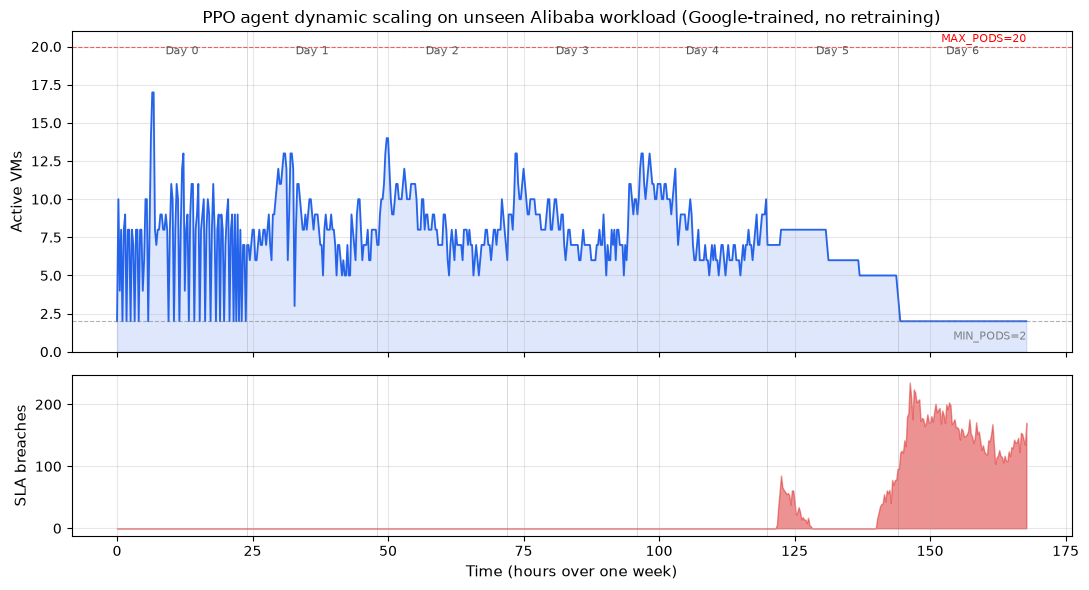

Saved. VM range: 2-17, mean 7.0


In [6]:
import matplotlib.pyplot as plt
import numpy as np

# ── collect VM count AND workload over one Alibaba week ──────────────────
env = CloudClusterEnv(alibaba_stats)
obs, _ = env.reset()
obs = torch.tensor(obs, dtype=torch.float32)

vms_over_time = []
arrivals_over_time = []
breaches_over_time = []

for t in range(STEPS_PER_WEEK):
    with torch.no_grad():
        mean, _ = gen_net.forward(obs.unsqueeze(0))
    obs, r, done, tr, info = env.step(mean.squeeze(0).numpy())
    obs = torch.tensor(obs, dtype=torch.float32)
    vms_over_time.append(info['active_vms'])
    # approximate the load this step from the queue + processed
    arrivals_over_time.append(info.get('queue', 0))
    breaches_over_time.append(info['breaches'])
    if done:
        break

steps = np.arange(len(vms_over_time))
hours = steps * 15 / 60.0   # convert steps to hours (15-min steps)

# ── plot: VM count over the week, with day boundaries ────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True,
                                gridspec_kw={'height_ratios': [2, 1]})

# top: VM count
ax1.plot(hours, vms_over_time, color='#2563eb', linewidth=1.3)
ax1.fill_between(hours, vms_over_time, alpha=0.15, color='#2563eb')
ax1.axhline(2, color='gray', ls='--', lw=0.8, alpha=0.6)
ax1.axhline(20, color='red', ls='--', lw=0.8, alpha=0.6)
ax1.text(hours[-1], 20.3, 'MAX_PODS=20', ha='right', fontsize=8, color='red')
ax1.text(hours[-1], 0.8, 'MIN_PODS=2', ha='right', fontsize=8, color='gray')
ax1.set_ylabel('Active VMs', fontsize=11)
ax1.set_title('PPO agent dynamic scaling on unseen Alibaba workload '
              '(Google-trained, no retraining)', fontsize=12)
ax1.set_ylim(0, 21)
ax1.grid(True, alpha=0.3)

# day boundaries
for d in range(1, 7):
    ax1.axvline(d*24, color='gray', lw=0.5, alpha=0.4)
    ax2.axvline(d*24, color='gray', lw=0.5, alpha=0.4)

# bottom: breaches over time (where it struggled)
ax2.fill_between(hours, breaches_over_time, color='#dc2626', alpha=0.5)
ax2.set_ylabel('SLA breaches', fontsize=11)
ax2.set_xlabel('Time (hours over one week)', fontsize=11)
ax2.grid(True, alpha=0.3)

# day labels
for d in range(7):
    ax1.text(d*24+12, 19.5, f'Day {d}', ha='center', fontsize=8, color='#555')

plt.tight_layout()
plt.savefig('alibaba_vm_over_time.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved. VM range: {min(vms_over_time)}-{max(vms_over_time)}, "
      f"mean {np.mean(vms_over_time):.1f}")